# 06 · 베이지안 추정 — 각 번호의 진짜 확률과 불확실성

> Part 6 · *"균등한가?"(빈도주의) 대신 "각 번호 확률은 얼마이고, 얼마나 확신하나?"(베이지안)를 묻는다.*

빈도주의 χ²는 "카운트가 균등과 부합하는가?"에 답합니다(그렇다). 하지만 도박꾼에게 더 쓸모 있는 질문은
**"이 데이터가 주어졌을 때 각 번호의 확률과 그 불확실성은?"**입니다. **켤레(conjugate) 사전분포**를
쓰면 후분포가 닫힌 형태로 나와 MCMC 없이도 계산됩니다 — 완벽한 교육 예제입니다.

모형 (번호 $i$, 전체 $N$회):
$$k_i \sim \text{Binomial}(N,\theta_i),\quad \theta_i\sim\text{Beta}(\alpha,\beta)
\;\Rightarrow\; \theta_i\mid k_i \sim \text{Beta}(\alpha+k_i,\ \beta+N-k_i)$$

공정값은 $\theta=6/45\approx0.1333$. 배울 것: **신용구간(credible interval)**, **축소(shrinkage)**,
그리고 왜 핫/콜드 스트릭이 신기루인지.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.lotto_ds import viz, bayesian as by
from src.lotto_ds.cleaning import load_clean

viz.apply_style()
draws = load_clean("draws")

## 1. 후분포 표
각 번호의 사후 평균과 95% 신용구간을 계산합니다. `prior_strength=45`는 공정값 6/45에 중심을 둔
약한 사전분포(45회 상당의 가상 데이터)입니다.

In [2]:
tbl = by.posterior_table(draws, prior_strength=45)
print("공정값 θ = 6/45 =", round(by.FAIR_THETA, 4))
print(tbl[["number","appearances","empirical_rate","posterior_mean","ci_lo","ci_hi","ci_contains_fair"]]
      .head(6).to_string(index=False))
print(f"\n45개 번호 중 신용구간이 공정값을 포함하는 개수: {int(tbl['ci_contains_fair'].sum())}/45")

공정값 θ = 6/45 = 0.1333
 number  appearances  empirical_rate  posterior_mean    ci_lo    ci_hi  ci_contains_fair
      1          169        0.137398        0.137255 0.118921 0.156666              True
      2          154        0.125203        0.125490 0.107879 0.144214              True
      3          172        0.139837        0.139608 0.121136 0.159151              True
      4          161        0.130894        0.130980 0.113026 0.150031              True
      5          153        0.124390        0.124706 0.107145 0.143382              True
      6          165        0.134146        0.134118 0.115972 0.153350              True

45개 번호 중 신용구간이 공정값을 포함하는 개수: 44/45


## 2. 신용구간 forest plot
각 번호의 사후 평균(점)과 95% 신용구간(선), 그리고 공정값 6/45(붉은 세로선).

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


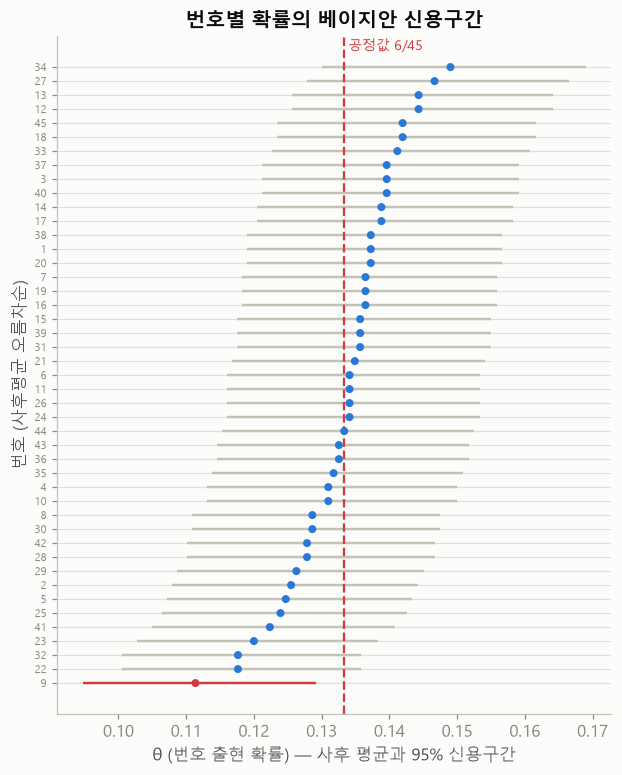

In [3]:
tbl_s = tbl.sort_values("posterior_mean").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(6.5, 8))
y = np.arange(len(tbl_s))
inside = tbl_s["ci_contains_fair"]
ax.hlines(y, tbl_s["ci_lo"], tbl_s["ci_hi"],
          color=[viz.INK["baseline"] if v else viz.STATUS["critical"] for v in inside], lw=1.6)
ax.scatter(tbl_s["posterior_mean"], y, s=18,
           color=[viz.CAT[0] if v else viz.STATUS["critical"] for v in inside], zorder=3)
ax.axvline(by.FAIR_THETA, color=viz.STATUS["critical"], ls="--", lw=1.5)
ax.text(by.FAIR_THETA, len(y), " 공정값 6/45", color=viz.STATUS["critical"], fontsize=9, va="bottom")
ax.set_yticks(y, tbl_s["number"], fontsize=7)
ax.set_xlabel("θ (번호 출현 확률) — 사후 평균과 95% 신용구간")
ax.set_ylabel("번호 (사후평균 오름차순)")
ax.set_title("번호별 확률의 베이지안 신용구간")
viz.savefig(fig, "06_credible_intervals.png"); plt.show()

거의 모든 구간이 공정값을 포함합니다. 포함하지 않는 소수는 **45개 구간 × 5% ≈ 2개**로,
완벽히 공정해도 우연히 나오는 수준입니다(다중검정과 같은 논리).

## 3. 축소(Shrinkage) — 회귀를 향한 후퇴의 시각화
사후 평균은 잡음 많은 경험적 비율을 사전분포(6/45) 쪽으로 **끌어당깁니다**. 이것이 "핫 넘버"가
다음 회차에 평범해지는 통계적 이유입니다.

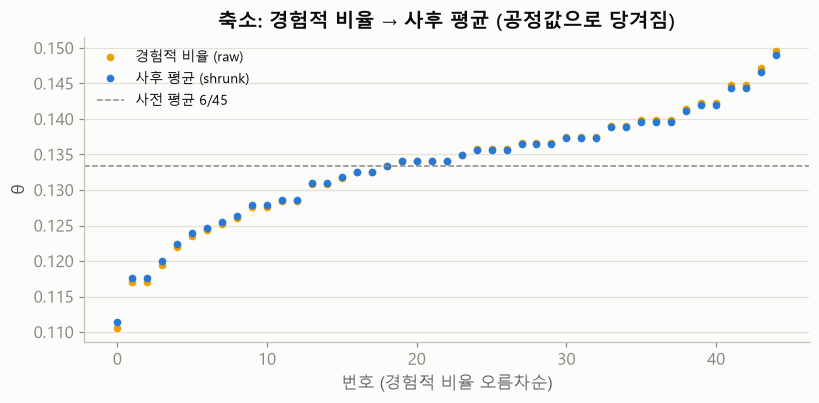

경험적 비율 범위: 0.1106 ~ 0.1496
사후 평균  범위: 0.1114 ~ 0.149 (더 좁아짐 = 축소)


In [4]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
order = tbl.sort_values("empirical_rate")
x = np.arange(len(order))
ax.plot(x, order["empirical_rate"], "o", ms=4, color=viz.CAT[2], label="경험적 비율 (raw)")
ax.plot(x, order["posterior_mean"], "o", ms=4, color=viz.CAT[0], label="사후 평균 (shrunk)")
ax.axhline(by.FAIR_THETA, ls="--", color=viz.INK["muted"], lw=1, label="사전 평균 6/45")
ax.set_title("축소: 경험적 비율 → 사후 평균 (공정값으로 당겨짐)")
ax.set_xlabel("번호 (경험적 비율 오름차순)"); ax.set_ylabel("θ")
ax.legend(frameon=False, fontsize=9)
viz.savefig(fig, "06_shrinkage.png"); plt.show()

print("경험적 비율 범위:", round(order['empirical_rate'].min(),4), "~", round(order['empirical_rate'].max(),4))
print("사후 평균  범위:", round(order['posterior_mean'].min(),4), "~", round(order['posterior_mean'].max(),4),
      "(더 좁아짐 = 축소)")

⚠️ **흔한 함정**: 경험적 비율만 보고 "34번은 확률이 높다"고 단정. 베이지안은 표본 크기가 주는
*불확실성*을 신용구간으로 정량화하고, 사전 지식으로 잡음을 축소합니다. 원자료 비율은 과신을 부릅니다.

### 정리
- 켤레 Beta-Binomial로 각 번호 확률을 불확실성과 함께 닫힌 형태로 추정.
- 44/45 신용구간이 공정값 포함 — 데이터는 균등과 완전히 부합.
- 축소는 "핫 넘버"의 평균 회귀를 수학적으로 설명.
- 다음: **07 · 올바른 머신러닝** — 강력한 모델도 신호를 못 찾는다.